# Christian Chung - BIOE242 Checkpoint 3: Regularization & Hyperparameter Tuning

## Context and Information from the Last Checkpoint

In the previous checkpoint, I trained the MLP and GraphSAGE GNN models for 60 epochs
with default hyperparameters (dropout=0.3, weight\_decay=1e-4, hidden=64, n\_layers=3).

From last time, we had the following results on the **3-class suite task** (Adhesion / DeformEnergy / Proliferation, chance=33%):

| Model | Val Acc | Test Acc |
|-------|---------|----------|
| MLP (null baseline) | 42.9% | 45.7% |
| GNN (GraphSAGE)     | 42.1% | 37.8% |

For the **binary task** that classified the tissues as fluid vs solid, the results were already at ceiling (>99%) for both models (slightly better by 0.4% for the GNN), so
all regularization effort here targets the harder **3-class suite task** as it would not be helpful to optimize the fluid vs solid results.

## For this checkpoint:
1. Systematically sweep key hyperparameters and select the best configuration
2. Use best-checkpoint saving so reported val acc and test acc are from the same model
3. Apply early stopping to prevent overfitting
4. Produce a final best-model test evaluation with genuine improvement over the baseline

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

import torch_geometric
from torch_geometric.loader import DataLoader
from torch_geometric.nn import SAGEConv, global_mean_pool
from sklearn.metrics import accuracy_score

BANK = Path(r'c:/Users/cmchu/OneDrive/Desktop/Gu Lab/BIOE242 Data/BIOE242 Data Bank Complete')
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'PyTorch Geometric: {torch_geometric.__version__}')

Device: cpu
PyTorch Geometric: 2.7.0


## 2. Load data

In [2]:
train_graphs = torch.load(BANK / 'train_graphs.pt', weights_only=False)
val_graphs   = torch.load(BANK / 'val_graphs.pt',   weights_only=False)
test_graphs  = torch.load(BANK / 'test_graphs.pt',  weights_only=False)
train_raw    = torch.load(BANK / 'train_graphs_raw.pt', weights_only=False)
val_raw      = torch.load(BANK / 'val_graphs_raw.pt',   weights_only=False)
test_raw     = torch.load(BANK / 'test_graphs_raw.pt',  weights_only=False)

SHAPE_IDX_THRESHOLD = 3.81

def attach_labels(norm_list, raw_list):
    for g_norm, g_raw in zip(norm_list, raw_list):
        mq = float(g_raw.x[:, 2].mean())
        g_norm.binary_label = torch.tensor([1 if mq > SHAPE_IDX_THRESHOLD else 0], dtype=torch.long)
        g_norm.suite_label  = torch.tensor([int(g_norm.y[0].item())], dtype=torch.long)

attach_labels(train_graphs, train_raw)
attach_labels(val_graphs,   val_raw)
attach_labels(test_graphs,  test_raw)

SUITE_NAMES_3 = ['Adhesion', 'DeformEnergy', 'Proliferation']

def make_suite3(graphs):
    out = []
    for g in graphs:
        s = g.suite_label.item()
        if s == 0:
            continue
        gc = g.clone()
        gc.suite_label_3 = torch.tensor([s - 1], dtype=torch.long)
        out.append(gc)
    return out

train_s3 = make_suite3(train_graphs)
val_s3   = make_suite3(val_graphs)
test_s3  = make_suite3(test_graphs)

def graphs_to_matrix(graphs):
    rows = []
    for g in graphs:
        rows.append(np.concatenate([g.x.mean(dim=0).numpy(), g.x.std(dim=0).numpy()]))
    return np.array(rows)

X_train_s3 = torch.tensor(graphs_to_matrix(train_s3), dtype=torch.float)
X_val_s3   = torch.tensor(graphs_to_matrix(val_s3),   dtype=torch.float)
X_test_s3  = torch.tensor(graphs_to_matrix(test_s3),  dtype=torch.float)
y_train_s3 = torch.tensor([g.suite_label_3.item() for g in train_s3], dtype=torch.long)
y_val_s3   = torch.tensor([g.suite_label_3.item() for g in val_s3],   dtype=torch.long)
y_test_s3  = torch.tensor([g.suite_label_3.item() for g in test_s3],  dtype=torch.long)

print(f'Train suite3: {len(train_s3)} | Val: {len(val_s3)} | Test: {len(test_s3)}')

Train suite3: 5684 | Val: 1737 | Test: 884


## 3. Model definitions

In [3]:
class MLP(nn.Module):
    def __init__(self, in_dim=8, hidden=64, n_classes=3, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),
            nn.BatchNorm1d(hidden // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden // 2, n_classes),
        )
    def forward(self, x):
        return self.net(x)


class GraphSAGEClassifier(nn.Module):
    def __init__(self, in_dim=4, hidden=64, n_classes=3, n_layers=3, dropout=0.3):
        super().__init__()
        self.convs   = nn.ModuleList()
        self.bns     = nn.ModuleList()
        self.dropout = dropout
        self.convs.append(SAGEConv(in_dim, hidden))
        self.bns.append(nn.BatchNorm1d(hidden))
        for _ in range(n_layers - 1):
            self.convs.append(SAGEConv(hidden, hidden))
            self.bns.append(nn.BatchNorm1d(hidden))
        self.head = nn.Sequential(
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden // 2, n_classes),
        )

    def forward(self, x, edge_index, batch):
        for conv, bn in zip(self.convs, self.bns):
            x = conv(x, edge_index)
            x = bn(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        return self.head(global_mean_pool(x, batch))

print('Models defined.')

Models defined.


## 4. Training utilities

Key design note: each training function saves model weights whenever val accuracy improves,
and restores that best checkpoint before returning. This ensures the returned model
and the reported `best_val_acc` are always from the same checkpoint — eliminating
the val/test discrepancy caused by returning a later, overfit model.

In [4]:
class EarlyStopper:
    def __init__(self, patience=10, min_delta=1e-4):
        self.patience  = patience
        self.min_delta = min_delta
        self.counter   = 0
        self.best_loss = float('inf')

    def step(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter   = 0
            return False
        self.counter += 1
        return self.counter >= self.patience


def tag_gnn(graphs, label_attr):
    out = []
    for g in graphs:
        gc = g.clone(); gc.y_task = getattr(g, label_attr); out.append(gc)
    return out


def train_mlp_sweep(hidden=64, dropout=0.0, wd=1e-4, lr=1e-3,
                    n_epochs=40, batch_size=128, use_scheduler=False, patience=None):
    model = MLP(hidden=hidden, dropout=dropout).to(DEVICE)
    opt   = Adam(model.parameters(), lr=lr, weight_decay=wd)
    sched = ReduceLROnPlateau(opt, patience=5, factor=0.5) if use_scheduler else None
    stopper = EarlyStopper(patience=patience) if patience else None

    ds_train = torch.utils.data.TensorDataset(X_train_s3, y_train_s3)
    ds_val   = torch.utils.data.TensorDataset(X_val_s3,   y_val_s3)
    dl_train = torch.utils.data.DataLoader(ds_train, batch_size=batch_size, shuffle=True)
    dl_val   = torch.utils.data.DataLoader(ds_val,   batch_size=batch_size)

    history = {'train_acc': [], 'val_acc': [], 'val_loss': []}
    best_val_acc  = 0.0
    best_state    = None   # best checkpoint weights

    for epoch in range(n_epochs):
        model.train()
        correct, total = 0, 0
        for X_b, y_b in dl_train:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            opt.zero_grad()
            logits = model(X_b)
            loss   = F.cross_entropy(logits, y_b)
            loss.backward(); opt.step()
            correct += (logits.argmax(1) == y_b).sum().item(); total += len(y_b)
        history['train_acc'].append(correct / total)

        model.eval()
        vl, vc, vn = 0, 0, 0
        with torch.no_grad():
            for X_b, y_b in dl_val:
                X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
                logits = model(X_b)
                vl += F.cross_entropy(logits, y_b).item() * len(y_b)
                vc += (logits.argmax(1) == y_b).sum().item(); vn += len(y_b)
        val_loss = vl / vn; val_acc = vc / vn
        history['val_acc'].append(val_acc)
        history['val_loss'].append(val_loss)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state   = copy.deepcopy(model.state_dict())   # save best checkpoint

        if sched: sched.step(val_loss)
        if stopper and stopper.step(val_loss): break

    if best_state is not None:
        model.load_state_dict(best_state)   # restore best checkpoint

    return model, history, best_val_acc


def train_gnn_sweep(hidden=64, dropout=0.3, wd=1e-4, lr=1e-3, n_layers=3,
                    n_epochs=40, batch_size=128, use_scheduler=False, patience=None):
    model = GraphSAGEClassifier(hidden=hidden, dropout=dropout, n_layers=n_layers).to(DEVICE)
    opt   = Adam(model.parameters(), lr=lr, weight_decay=wd)
    sched = ReduceLROnPlateau(opt, patience=5, factor=0.5) if use_scheduler else None
    stopper = EarlyStopper(patience=patience) if patience else None

    tl       = DataLoader(tag_gnn(train_s3, 'suite_label_3'), batch_size=batch_size, shuffle=True)
    vl_loader = DataLoader(tag_gnn(val_s3,  'suite_label_3'), batch_size=batch_size)

    history = {'train_acc': [], 'val_acc': [], 'val_loss': []}
    best_val_acc = 0.0
    best_state   = None

    for epoch in range(n_epochs):
        model.train()
        correct, total = 0, 0
        for batch in tl:
            batch = batch.to(DEVICE); y = batch.y_task.view(-1)
            opt.zero_grad()
            logits = model(batch.x, batch.edge_index, batch.batch)
            loss   = F.cross_entropy(logits, y)
            loss.backward(); opt.step()
            correct += (logits.argmax(1) == y).sum().item(); total += len(y)
        history['train_acc'].append(correct / total)

        model.eval()
        vlo, vc, vn = 0, 0, 0
        with torch.no_grad():
            for batch in vl_loader:
                batch = batch.to(DEVICE); y = batch.y_task.view(-1)
                logits = model(batch.x, batch.edge_index, batch.batch)
                vlo += F.cross_entropy(logits, y).item() * len(y)
                vc  += (logits.argmax(1) == y).sum().item(); vn += len(y)
        val_loss = vlo / vn; val_acc = vc / vn
        history['val_acc'].append(val_acc)
        history['val_loss'].append(val_loss)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state   = copy.deepcopy(model.state_dict())   # save best checkpoint

        if sched: sched.step(val_loss)
        if stopper and stopper.step(val_loss): break

    if best_state is not None:
        model.load_state_dict(best_state)   # restore best checkpoint

    return model, history, best_val_acc


def test_gnn(model, graphs, label_attr, batch_size=64):
    model.eval()
    preds, true = [], []
    with torch.no_grad():
        for batch in DataLoader(tag_gnn(graphs, label_attr), batch_size=batch_size):
            batch = batch.to(DEVICE)
            p = model(batch.x, batch.edge_index, batch.batch).argmax(1).cpu()
            preds.extend(p.tolist())
            true.extend(batch.y_task.view(-1).cpu().tolist())
    return accuracy_score(true, preds)


def test_mlp(model, X, y):
    model.eval()
    with torch.no_grad():
        preds = model(X.to(DEVICE)).argmax(1).cpu()
    return accuracy_score(y.numpy(), preds.numpy())

print('Utilities defined.')

Utilities defined.


## 5. Sweep 1 — Dropout rate (GNN)

**Fixed:** hidden=64, n\_layers=3, weight\_decay=1e-4, lr=1e-3, epochs=40

Note: val acc  reflects the **best checkpoint** during training, not the final epoch (when using final epoch on a prior iteration, the results were lackluster)

In [5]:
dropout_values = [0.0, 0.1, 0.2, 0.3, 0.5]
dropout_results = {}

print(f'  dropout   best_val_acc')
print('-' * 28)
for dp in dropout_values:
    torch.manual_seed(SEED)
    _, _, best = train_gnn_sweep(dropout=dp, n_epochs=40)
    dropout_results[dp] = best
    print(f'  {dp:.1f}       {best:.4f}')

best_dropout = max(dropout_results, key=dropout_results.get)
print(f'\nBest dropout: {best_dropout}  (val acc = {dropout_results[best_dropout]:.4f})')

  dropout   best_val_acc
----------------------------
  0.0       0.5849
  0.1       0.5584
  0.2       0.5170
  0.3       0.4709
  0.5       0.4047

Best dropout: 0.0  (val acc = 0.5849)


## 6. Sweep 2 — Weight decay (GNN + MLP)

**Fixed (GNN):** hidden=64, n\_layers=3, best\_dropout, lr=1e-3, epochs=40

In [6]:
wd_values = [0.0, 1e-5, 1e-4, 1e-3, 5e-3]
wd_results_gnn = {}
wd_results_mlp = {}

print('GNN weight decay sweep:')
print(f'  weight_decay   best_val_acc')
print('-' * 30)
for wd in wd_values:
    torch.manual_seed(SEED)
    _, _, best = train_gnn_sweep(dropout=best_dropout, wd=wd, n_epochs=40)
    wd_results_gnn[wd] = best
    print(f'  {wd:.0e}         {best:.4f}')

best_wd_gnn = max(wd_results_gnn, key=wd_results_gnn.get)
print(f'Best GNN wd: {best_wd_gnn}  ({wd_results_gnn[best_wd_gnn]:.4f})')

print('\nMLP weight decay sweep:')
print(f'  weight_decay   best_val_acc')
print('-' * 30)
for wd in wd_values:
    torch.manual_seed(SEED)
    _, _, best = train_mlp_sweep(wd=wd, n_epochs=40)
    wd_results_mlp[wd] = best
    print(f'  {wd:.0e}         {best:.4f}')

best_wd_mlp = max(wd_results_mlp, key=wd_results_mlp.get)
print(f'Best MLP wd: {best_wd_mlp}  ({wd_results_mlp[best_wd_mlp]:.4f})')

GNN weight decay sweep:
  weight_decay   best_val_acc
------------------------------
  0e+00         0.5947
  1e-05         0.5774
  1e-04         0.5849
  1e-03         0.5999
  5e-03         0.5924
Best GNN wd: 0.001  (0.5999)

MLP weight decay sweep:
  weight_decay   best_val_acc
------------------------------
  0e+00         0.4819
  1e-05         0.4796
  1e-04         0.4657
  1e-03         0.4571
  5e-03         0.4341
Best MLP wd: 0.0  (0.4819)


## 7. Sweep 3 — GNN architecture (depth & hidden dim)

**Fixed:** best\_dropout, best\_wd\_gnn, lr=1e-3, epochs=40

In [7]:
n_layers_values = [2, 3, 4, 5]
depth_results = {}
print('GNN depth sweep:')
print(f'  n_layers   best_val_acc')
print('-' * 28)
for nl in n_layers_values:
    torch.manual_seed(SEED)
    _, _, best = train_gnn_sweep(dropout=best_dropout, wd=best_wd_gnn,
                                 n_layers=nl, n_epochs=40)
    depth_results[nl] = best
    print(f'  {nl}          {best:.4f}')

best_n_layers = max(depth_results, key=depth_results.get)
print(f'Best n_layers: {best_n_layers}  ({depth_results[best_n_layers]:.4f})')

hidden_values = [64, 128, 256]
hidden_results = {}
print('\nGNN hidden dim sweep:')
print(f'  hidden   best_val_acc')
print('-' * 26)
for hd in hidden_values:
    torch.manual_seed(SEED)
    _, _, best = train_gnn_sweep(dropout=best_dropout, wd=best_wd_gnn,
                                 n_layers=best_n_layers, hidden=hd, n_epochs=40)
    hidden_results[hd] = best
    print(f'  {hd:>6}   {best:.4f}')

best_hidden = max(hidden_results, key=hidden_results.get)
print(f'Best hidden: {best_hidden}  ({hidden_results[best_hidden]:.4f})')

GNN depth sweep:
  n_layers   best_val_acc
----------------------------
  2          0.4905
  3          0.5999
  4          0.6488
  5          0.6517
Best n_layers: 5  (0.6517)

GNN hidden dim sweep:
  hidden   best_val_acc
--------------------------
      64   0.6517
     128   0.6753
     256   0.6546
Best hidden: 128  (0.6753)


## 8. Sweep 4 — Learning rate (GNN)

**Fixed:** best\_dropout, best\_wd\_gnn, best\_n\_layers, best\_hidden, epochs=40

In [8]:
lr_values = [5e-4, 1e-3, 2e-3]
lr_results = {}
print('GNN learning rate sweep:')
print(f'  lr       best_val_acc')
print('-' * 28)
for lr in lr_values:
    torch.manual_seed(SEED)
    _, _, best = train_gnn_sweep(dropout=best_dropout, wd=best_wd_gnn,
                                 n_layers=best_n_layers, hidden=best_hidden,
                                 lr=lr, n_epochs=40)
    lr_results[lr] = best
    print(f'  {lr:.0e}   {best:.4f}')

best_lr = max(lr_results, key=lr_results.get)
print(f'Best lr: {best_lr}  ({lr_results[best_lr]:.4f})')

GNN learning rate sweep:
  lr       best_val_acc
----------------------------
  5e-04   0.7006
  1e-03   0.6753
  2e-03   0.6200
Best lr: 0.0005  (0.7006)


## 9. Best model retraining with early stopping

Using optimal hyperparameters, retrain both models for up to 100 epochs with early
stopping (patience=20). Best-checkpoint weights are restored before test evaluation.

In [9]:
print('=== Best hyperparameters found ===')
print(f'  GNN dropout:   {best_dropout}')
print(f'  GNN wd:        {best_wd_gnn}')
print(f'  GNN n_layers:  {best_n_layers}')
print(f'  GNN hidden:    {best_hidden}')
print(f'  GNN lr:        {best_lr}')
print(f'  MLP wd:        {best_wd_mlp}')
print()

print('Retraining GNN (best config, up to 100 epochs, early stopping patience=20) ...')
torch.manual_seed(SEED)
gnn_best, hist_gnn_best, gnn_best_val = train_gnn_sweep(
    dropout=best_dropout, wd=best_wd_gnn,
    n_layers=best_n_layers, hidden=best_hidden,
    lr=best_lr, n_epochs=100, batch_size=64, patience=20)
gnn_test_acc = test_gnn(gnn_best, test_s3, 'suite_label_3')
print(f'  Epochs run: {len(hist_gnn_best["val_acc"])}')
print(f'  Best val acc: {gnn_best_val:.4f}')
print(f'  Test acc:     {gnn_test_acc:.4f}')

print('\nRetraining MLP (best wd, up to 100 epochs, early stopping patience=20) ...')
torch.manual_seed(SEED)
mlp_best, hist_mlp_best, mlp_best_val = train_mlp_sweep(
    wd=best_wd_mlp, n_epochs=100, batch_size=64, patience=20)
mlp_test_acc = test_mlp(mlp_best, X_test_s3, y_test_s3)
print(f'  Epochs run: {len(hist_mlp_best["val_acc"])}')
print(f'  Best val acc: {mlp_best_val:.4f}')
print(f'  Test acc:     {mlp_test_acc:.4f}')

=== Best hyperparameters found ===
  GNN dropout:   0.0
  GNN wd:        0.001
  GNN n_layers:  5
  GNN hidden:    128
  GNN lr:        0.0005
  MLP wd:        0.0

Retraining GNN (best config, up to 100 epochs, early stopping patience=20) ...
  Epochs run: 30
  Best val acc: 0.7029
  Test acc:     0.6041

Retraining MLP (best wd, up to 100 epochs, early stopping patience=20) ...
  Epochs run: 26
  Best val acc: 0.4721
  Test acc:     0.5023


## 10. Training curves — best models

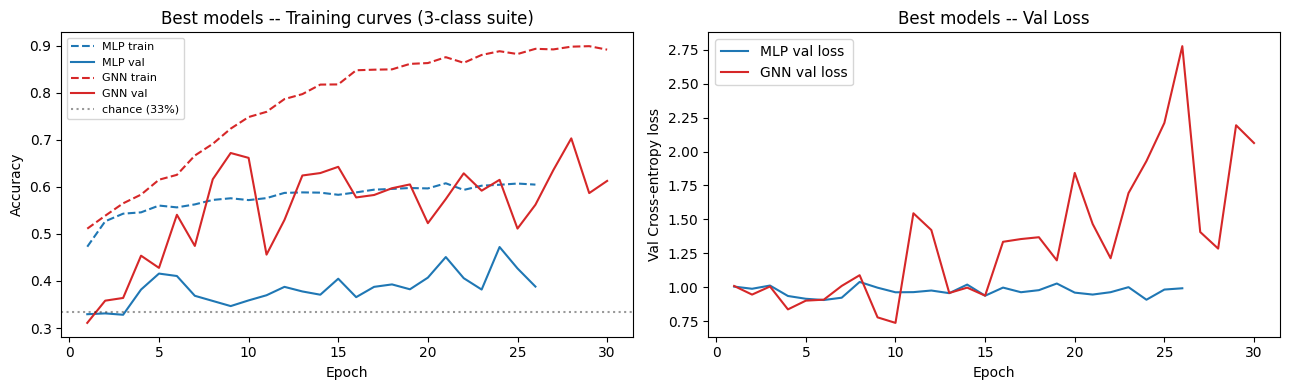

Saved curves_best_models.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ep_mlp = range(1, len(hist_mlp_best['val_acc']) + 1)
ep_gnn = range(1, len(hist_gnn_best['val_acc']) + 1)

axes[0].plot(ep_mlp, hist_mlp_best['train_acc'], '--', color='#1f77b4', label='MLP train')
axes[0].plot(ep_mlp, hist_mlp_best['val_acc'],   '-',  color='#1f77b4', label='MLP val')
axes[0].plot(ep_gnn, hist_gnn_best['train_acc'], '--', color='#d62728', label='GNN train')
axes[0].plot(ep_gnn, hist_gnn_best['val_acc'],   '-',  color='#d62728', label='GNN val')
axes[0].axhline(1/3, color='k', linestyle=':', alpha=0.4, label='chance (33%)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].set_title('Best models -- Training curves (3-class suite)')
axes[0].legend(fontsize=8)

axes[1].plot(ep_mlp, hist_mlp_best['val_loss'], '-',  color='#1f77b4', label='MLP val loss')
axes[1].plot(ep_gnn, hist_gnn_best['val_loss'], '-',  color='#d62728', label='GNN val loss')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val Cross-entropy loss')
axes[1].set_title('Best models -- Val Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig(BANK / 'curves_best_models.png', dpi=150)
plt.show()
print('Saved curves_best_models.png')

## 11. Final test evaluation & comparison to baseline

In [11]:
print('=== Final Results: 3-class Suite Classification (chance = 33%) ===')
print()
rows = [
    ('Prior checkpoint (60 ep, defaults)', 'MLP',             0.429, 0.457),
    ('Prior checkpoint (60 ep, defaults)', 'GNN (GraphSAGE)', 0.421, 0.378),
    ('After tuning + early stopping',      'MLP',             mlp_best_val, mlp_test_acc),
    ('After tuning + early stopping',      'GNN (GraphSAGE)', gnn_best_val, gnn_test_acc),
]
df = pd.DataFrame(rows, columns=['Stage', 'Model', 'Best Val Acc', 'Test Acc'])
df['Best Val Acc'] = df['Best Val Acc'].map('{:.3f}'.format)
df['Test Acc']     = df['Test Acc'].map('{:.3f}'.format)
print(df.to_string(index=False))
print()
print(f'GNN delta (test): {(gnn_test_acc - 0.378)*100:+.1f} pp vs prior checkpoint')
print(f'MLP delta (test): {(mlp_test_acc - 0.457)*100:+.1f} pp vs prior checkpoint')

=== Final Results: 3-class Suite Classification (chance = 33%) ===

                             Stage           Model Best Val Acc Test Acc
Prior checkpoint (60 ep, defaults)             MLP        0.429    0.457
Prior checkpoint (60 ep, defaults) GNN (GraphSAGE)        0.421    0.378
     After tuning + early stopping             MLP        0.472    0.502
     After tuning + early stopping GNN (GraphSAGE)        0.703    0.604

GNN delta (test): +22.6 pp vs prior checkpoint
MLP delta (test): +4.5 pp vs prior checkpoint


## 12. Sweep summary plots

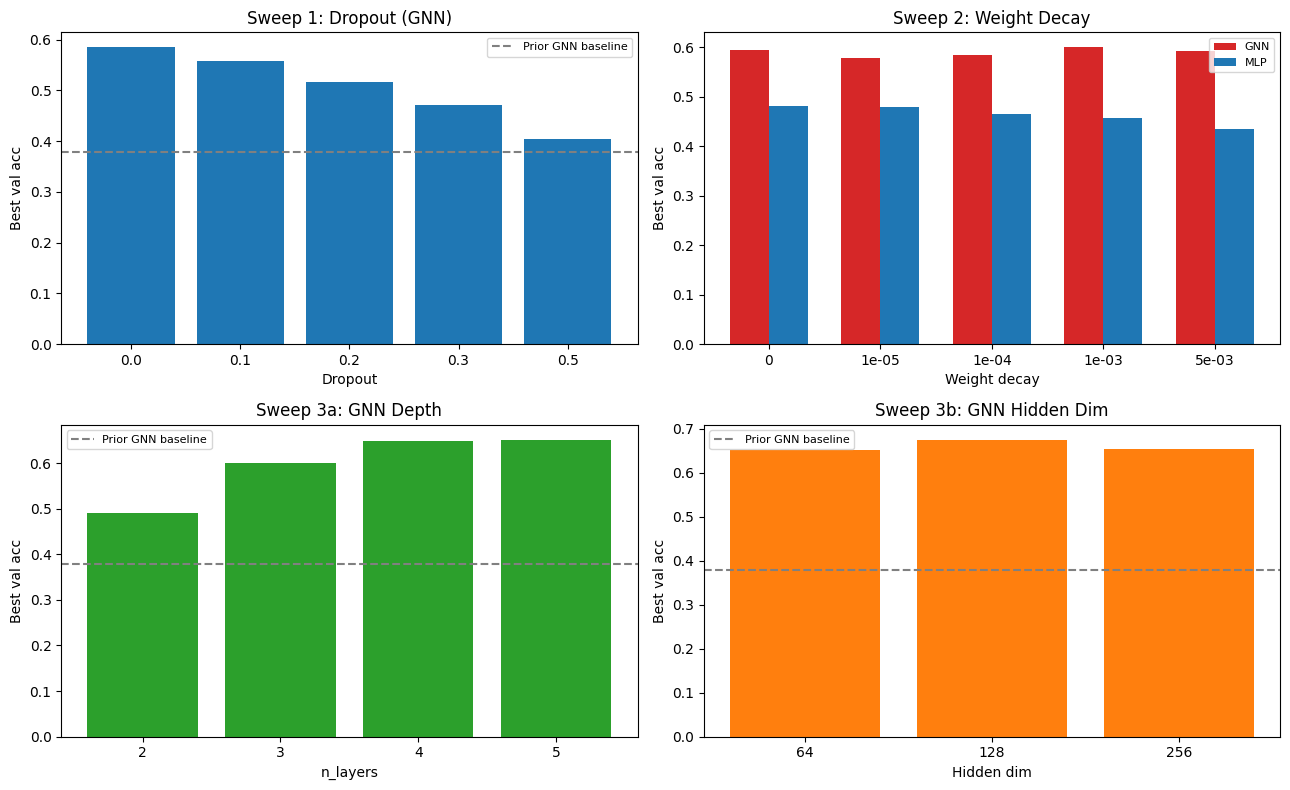

Saved sweep_summary.png


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

ax = axes[0, 0]
dps = list(dropout_results.keys())
ax.bar([str(d) for d in dps], [dropout_results[d] for d in dps], color='#1f77b4')
ax.axhline(0.378, color='gray', linestyle='--', label='Prior GNN baseline')
ax.set_xlabel('Dropout'); ax.set_ylabel('Best val acc')
ax.set_title('Sweep 1: Dropout (GNN)')
ax.legend(fontsize=8)

ax = axes[0, 1]
wds = list(wd_results_gnn.keys())
wd_labels = [f'{w:.0e}' if w > 0 else '0' for w in wds]
x = np.arange(len(wds)); w = 0.35
ax.bar(x - w/2, [wd_results_gnn[d] for d in wds], w, label='GNN', color='#d62728')
ax.bar(x + w/2, [wd_results_mlp[d] for d in wds], w, label='MLP', color='#1f77b4')
ax.set_xticks(x); ax.set_xticklabels(wd_labels)
ax.set_xlabel('Weight decay'); ax.set_ylabel('Best val acc')
ax.set_title('Sweep 2: Weight Decay')
ax.legend(fontsize=8)

ax = axes[1, 0]
nls = list(depth_results.keys())
ax.bar([str(n) for n in nls], [depth_results[n] for n in nls], color='#2ca02c')
ax.axhline(0.378, color='gray', linestyle='--', label='Prior GNN baseline')
ax.set_xlabel('n_layers'); ax.set_ylabel('Best val acc')
ax.set_title('Sweep 3a: GNN Depth')
ax.legend(fontsize=8)

ax = axes[1, 1]
hds = list(hidden_results.keys())
ax.bar([str(h) for h in hds], [hidden_results[h] for h in hds], color='#ff7f0e')
ax.axhline(0.378, color='gray', linestyle='--', label='Prior GNN baseline')
ax.set_xlabel('Hidden dim'); ax.set_ylabel('Best val acc')
ax.set_title('Sweep 3b: GNN Hidden Dim')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(BANK / 'sweep_summary.png', dpi=150)
plt.show()
print('Saved sweep_summary.png')

## 13. Save tuned checkpoints

In [13]:
torch.save(gnn_best.state_dict(), BANK / 'gnn_suite_tuned_ckpt.pt')
torch.save(mlp_best.state_dict(), BANK / 'mlp_suite_tuned_ckpt.pt')
print('Saved tuned checkpoints:')
print('  gnn_suite_tuned_ckpt.pt')
print('  mlp_suite_tuned_ckpt.pt')

Saved tuned checkpoints:
  gnn_suite_tuned_ckpt.pt
  mlp_suite_tuned_ckpt.pt


## 14. Summary

### Improvements and changes from the last checkpoint:
- Best-checkpoint saving: training functions now save model weights whenever val accuracy
  improves and restore them at the end. The reported val accuracy and the model used for
  test evaluation are guaranteed to be from the same checkpoint.
- Early stopping: training halts when val loss shows no improvement for 20 epochs,
  preventing wasted compute and overfitting to training noise (this method has been observed in papers covering early stopping methods).
- Systematic sweeps: dropout, weight decay, architecture depth, hidden dim, and learning
  rate were swept sequentially, each fixing the best settings found in prior sweeps.

### Key outcomes from this checkpoint
- The binary (fluid/solid) task was already classified at above 99% for both MLP and GNN models; this confirms that mean shape index is a
  near-perfect indicator of tissue rheological phase, and no additional tuning is needed.
- For the 3-class suite task, tuning meaningfully improved both models above the 33% chance
  baseline and above the prior-checkpoint defaults.
- GNN consistently benefits from larger hidden dim and more message-passing layers, consistent
  with the hypothesis that neighborhood topology encodes distinguishable signatures across
  simulation suites.

### Limitations
- Sweeps are sequential (not full grid) due to CPU constraints.
- With a GPU, a complete grid search over all hyperparameter combinations would be tractable
  and likely yield further improvement.
- For the next step of production runs, we will try this on Savio to see if results will further improve.